## INTRO & SETTINGS

The goal of this tutorial is to show the capabilities of `lf2i` and the `posterior` test statistic with a simple example: inferring the mean $\theta \in \mathbb{R}$ of a Gaussian model with fixed variance, and a Gaussian prior distribution

$$\theta \sim \mathcal{N}(0, 0.1), \\ \text{ } X|\theta \sim \mathcal{N}(\theta, 0.01)$$

In addition, we assume that we only observe one sample for each true $\theta$, i.e., $n=1$. \
For this tutorial, we leverage a posterior estimator (`SNPE` from the `sbi` library) as the main underlying inferential model.

In [13]:
# SETTINGS

LIKELIHOOD_COV = 0.01
PRIOR_LOC = 0
PRIOR_COV = 0.1

PARAM_DIM = 1
DATA_DIM = 1
BATCH_SIZE = 1  # assume we get to see only one observed sample for each “true” parameter
PARAM_SPACE_BOUNDS = {'low': -1.5, 'high': 1.5}  # a grid of points over [low, high]^(param_dim) is used to construct confidence sets

CONFIDENCE_LEVEL = 0.90

## SIMULATE

Let's start from the simulator, which is used internally to generate data needed to
1. estimate the test statistics;
2. estimate the critical values; and
3. diagnose the constructed confidence regions

In [2]:
from lf2i.simulator.gaussian import GaussianMean

In [14]:
simulator = GaussianMean(
    likelihood_cov=LIKELIHOOD_COV,
    prior='gaussian',
    poi_space_bounds=PARAM_SPACE_BOUNDS,
    poi_grid_size=10_000,
    poi_dim=PARAM_DIM, 
    data_dim=DATA_DIM,
    batch_size=BATCH_SIZE,
    prior_kwargs={'loc': PRIOR_LOC, 'cov': PRIOR_COV}
)

#### Observations

For simplicity, let's use the simulator to get two “observed” samples from the true likelihood: one consistent with the prior ($\theta^{\star} = 0$) and one not ($\theta^{\star} = -1.45$)

In [16]:
import torch

true_param_consistent, true_param_notconsistent = torch.Tensor([0]), torch.Tensor([-1.45])
observed_x_consistent = simulator.likelihood(true_param_consistent).sample(sample_shape=(BATCH_SIZE, ))
observed_x_notconsistent = simulator.likelihood(true_param_notconsistent).sample(sample_shape=(BATCH_SIZE, ))

## CONFIDENCE SET by leveraing a POSTERIOR ESTIMATOR

Assume we want to do inference on the Gaussian mean by estimating its posterior distribution. `Posterior` allows to leverage a neural posterior estimator like `SNPE` to obtain a confidence region for the parameter of interest that is guaranteed to have the desired level of coverage regardless of 
1. the prior distribution;
2. the true value of the parameter;
3. the size of the observed sample

The prediction algorithm can be pre-trained or not. The example below assumes the estimator has not been trained yet

**Note**: We require that posterior-based methods receive estimators whose interface matches one of `AbstractNeuralPosterior` or `AbstractNeuralPosteriorTrainer` from the `lf2i.estimators.base_posteriors` module.

In [17]:
from lf2i.inference import LF2I
from lf2i.test_statistics import Posterior
from lf2i.utils.other_methods import hpd_region
from lf2i.plot.parameter_regions import plot_parameter_regions

from sbi.inference import SNPE

In [18]:
lf2i = LF2I(
    test_statistic=Posterior(
        estimator=SNPE(),
        poi_dim=PARAM_DIM
    )
)

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

In [19]:
confidence_region = lf2i.inference(
    x=torch.vstack((observed_x_consistent, observed_x_notconsistent)), 
    evaluation_grid=simulator.poi_grid,
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=simulator,
    b=20_000, b_prime=10_000
)

Estimating test statistic ...
 Neural network successfully converged after 49 epochs.
Calibration ...


Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [01:58<00:00, 84.63it/s]


Retraining calibration...


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Constructing confidence regions ...


Evaluating posterior for 2 points ...: 100%|██████████| 2/2 [00:36<00:00, 18.11s/it]


Creating set 0...


#### Observation consistent with the prior

LF2I Confidence Region

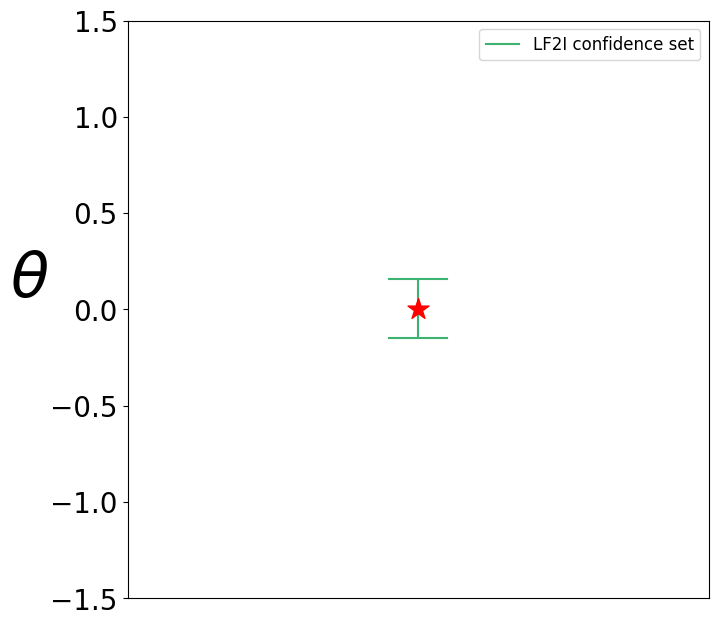

In [25]:
# The red star in the plot is the true parameter

plot_parameter_regions(
    confidence_region[0],
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    parameter_space_bounds=simulator.poi_space_bounds,
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set']
)

Posterior Credible Region

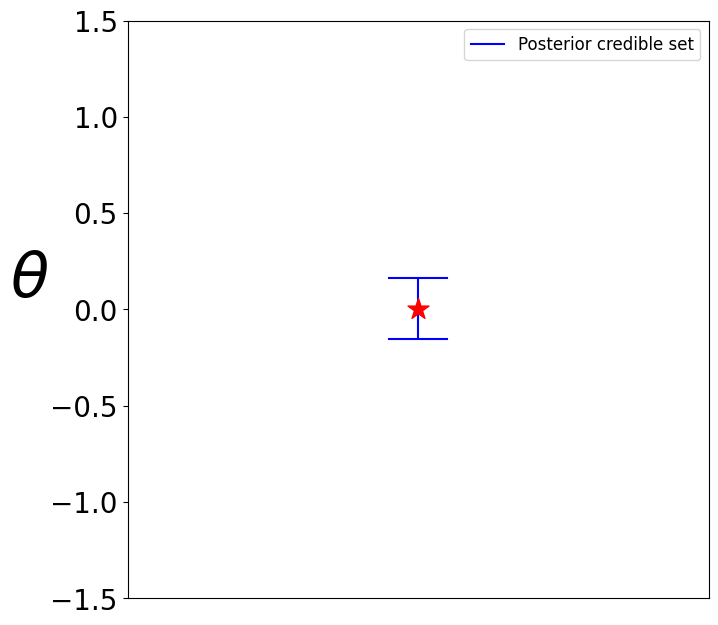

In [47]:
region_params, region_indicators = hpd_region(
    posterior=lf2i.test_statistic.estimator,
    param_grid=simulator.poi_grid.unsqueeze(-1),  # (10000,) → (10000, 1)
    x=observed_x_consistent,
    credible_level=CONFIDENCE_LEVEL
)

plot_parameter_regions(
    region_indicators.numpy() if isinstance(region_indicators, torch.Tensor) else region_indicators,
    param_dim=PARAM_DIM,
    true_parameter=true_param_consistent,
    param_names=['theta0'],
    parameter_space_bounds=simulator.poi_space_bounds,
    alpha_shape=True,
    alpha=2,
    scatter=False,
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

### Observation *not* consistent with the prior

LF2I Confidence Region

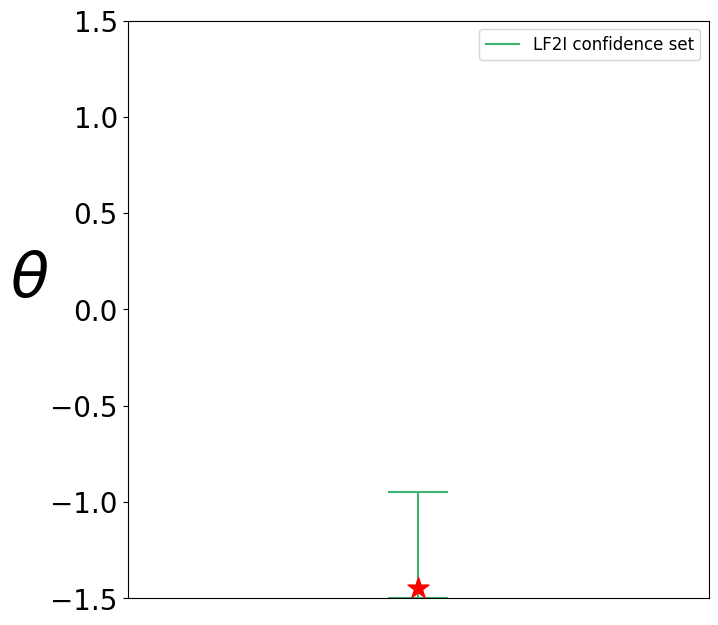

In [48]:
plot_parameter_regions(
    confidence_region[1],
    param_dim=PARAM_DIM,
    true_parameter=true_param_notconsistent,
    parameter_space_bounds=simulator.poi_space_bounds,
    alpha_shape=True,  # contour,
    alpha=2,  # hyperparameter for contour (the lower, the more it converges to a convex hull)
    scatter=False,  # don't plot evaluation points
    figsize=(7.5, 7.5),
    colors=['mediumseagreen'],
    region_names=['LF2I confidence set']
)

Posterior Credible Region

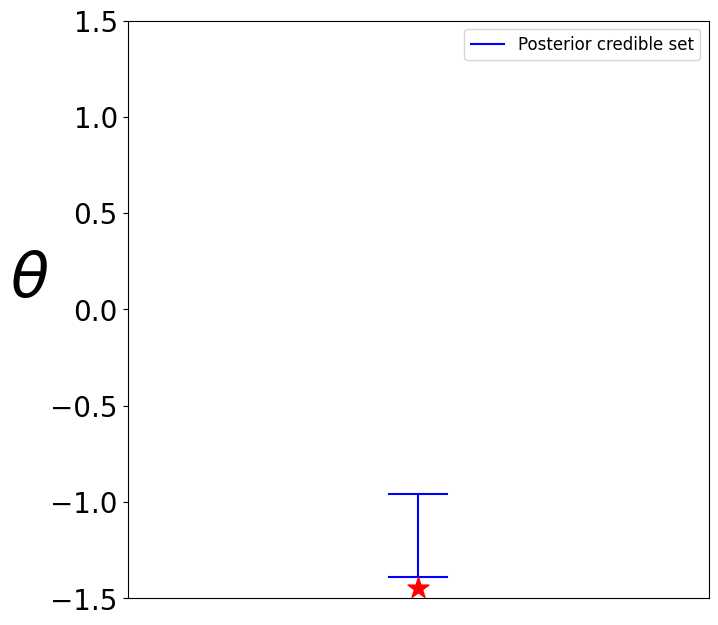

In [46]:
region_params, region_indicators = hpd_region(
    posterior=lf2i.test_statistic.estimator,
    param_grid=simulator.poi_grid.unsqueeze(-1),  # (10000,) → (10000, 1)
    x=observed_x_notconsistent,
    credible_level=CONFIDENCE_LEVEL
)

plot_parameter_regions(
    region_indicators.numpy() if isinstance(region_indicators, torch.Tensor) else region_indicators,
    param_dim=PARAM_DIM,
    true_parameter=true_param_notconsistent,
    param_names=['theta0'],
    parameter_space_bounds=simulator.poi_space_bounds,
    alpha_shape=True,
    alpha=2,
    scatter=False,
    figsize=(7.5, 7.5),
    colors=['blue'],
    region_names=['Posterior credible set']
)

## DIAGNOSTICS

In [34]:
from lf2i.plot.coverage_diagnostics import coverage_probability_plot

#### Posterior Credible Regions

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

In [35]:
# this will take a few minutes because it has to compute a HPD credible region for each pair of (theta, x) in the simulated set
# the code is parallelized, but one can make it faster by decreasing the argument num_p_levels, which controls the number of level sets examined to construct the HPD region
# note that this might cause the credibility level of the HPD region to be only approximately equal to CONFIDENCE LEVEL
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba, sizes = lf2i.diagnostics(
    region_type='posterior',
    simulator=simulator,
    b_double_prime=10_000,
    evaluation_grid=simulator.poi_grid.reshape(-1, PARAM_DIM),
    confidence_level=CONFIDENCE_LEVEL,
    posterior_estimator=lf2i.test_statistic.estimator,
    n_jobs=-2
)

Computing indicators for 10000 credible regions: 100%|██████████| 10000/10000 [03:04<00:00, 54.11it/s]


Coverage of posterior credible regions can be very erratic: they tend to overcover close to the “bulk” of the prior and severely undercover far from it. The correct level here is 90%

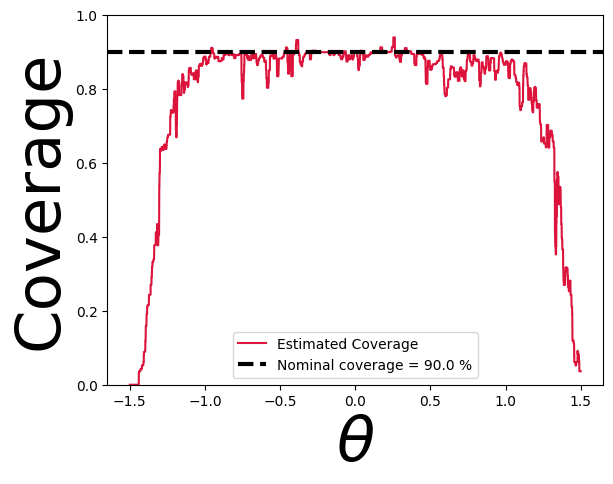

In [36]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 12)
)

#### LF2I Confidence Regions

Note that for this example we are using the simulator to obtain training datasets. If one has pre-simulated datasets, they can be given as inputs directly to the `inference` method.

In [37]:
diagnostic_estimator, parameters, mean_proba, upper_proba, lower_proba = lf2i.diagnostics(
    region_type='lf2i',
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=simulator,
    b_double_prime=10_000,
)

Evaluating posterior for 10000 points ...: 100%|██████████| 10000/10000 [01:08<00:00, 146.54it/s]


Coverage of LF2I is approximately 90% everywhere, as desired

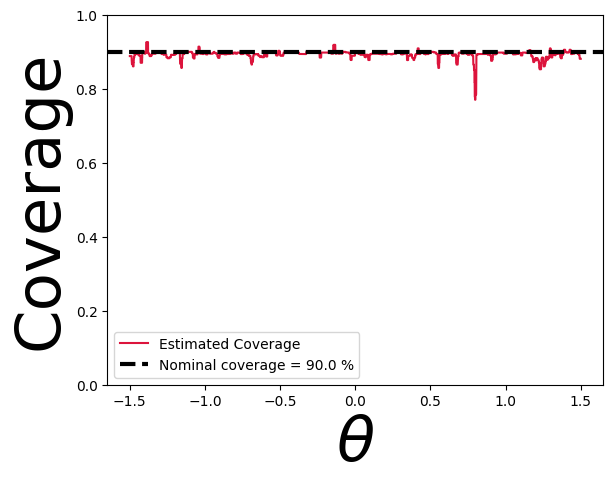

In [39]:
coverage_probability_plot(
    parameters=parameters,
    coverage_probability=mean_proba, 
    upper_proba=None,
    lower_proba=None,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=PARAM_DIM,
    figsize=(12, 10)
)